In [80]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START,END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [81]:
load_dotenv()

True

In [82]:
class State(TypedDict):
  question: str
  rewritten_question: str
  documents: list[Document]
  generation: str
  retrieval_attempts: int
  hallucination_attempts: int
  final_answer: str
  hallucination_grade: str

In [83]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [84]:
loader = PyPDFLoader('../intro-to-ml.pdf')
docs = loader.load()

In [85]:
len(docs)

392

In [86]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [87]:
len(chunks)

973

In [88]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = FAISS.from_documents(chunks,embeddings)

In [89]:
retriever = vector_store.as_retriever(search_type="similarity",search_kwargs={'k':3})

In [90]:
retriever.invoke(
  "What is machine learning"
)

[Document(id='fa2aa3a2-965d-4356-902f-d86e6df869a1', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': '../intro-to-ml.pdf', 'total_pages': 392, 'page': 14, 'page_label': '1'}, page_content='CHAPTER 1\nIntroduction\nMachine learning is about extracting knowledge from data. It is a research field at the\nintersection of statistics, artificial intelligence, and computer science and is also\nknown as predictive analytics or statistical learning. The application of machine\nlearning methods has in recent years become ubiquitous in everyday life. From auto‐\nmatic recommendations of which movies to watch, to what food to order or which\nprod

In [91]:
def retrieve(state: State):
  if state.get("rewritten_question"):
    docs = retriever.invoke(state["rewritten_question"])
  else:
    docs = retriever.invoke(state["question"])
  
  return {"documents": docs,"retrieval_attempts": state.get("retrieval_attempts",0) + 1}

In [92]:
def grade_documents(state: State):
  updated_docs = []

  for doc in state["documents"]:
    question = state["question"]
    prompt = f"""
    You are a grader assessing the relevance of a retrieved document to a user question.

    Document:
    {doc}

    User Question:
    {question}

    Give a binary score 'yes' or 'no' to indicate whether the document is relevant to the question.
    Respond with only 'yes' or 'no', nothing else.
"""
    
    response = llm.invoke(prompt)
    if response.content.lower() == 'yes':
      updated_docs.append(doc)


  return {"documents": updated_docs}

In [93]:
def rewrite_query(state: State):
  question = state["question"]
  prompt = f"""You are a question rewriter that improves questions for better vector store retrieval.

Original question: {question}

Rewrite this question to be more specific and better suited for document retrieval.
Return only the rewritten question, nothing else."""
  response = llm.invoke(prompt).content

  return {"rewritten_question": response}

def cannot_answer(state: State):
  return {"final_answer": "Cannot answer"}

def generate(state: State):
  documents = state["documents"]
  question = state["rewritten_question"] if state.get("rewritten_question") else state["question"]

  prompt = f"""You are an assistant answering questions based on provided documents.

    Documents:
    {documents}

    Question:
    {question}

    Answer the question using only the information from the documents.
    If the documents don't contain enough information, say so."""
  
  response = llm.invoke(prompt).content

  return {"generation": response}


In [94]:
# keep routing and state mutation seperate
def check_condition(state: State):
  if len(state["documents"]) < 2 and state["retrieval_attempts"] < 3:
    return "rewrite_query"
  elif len(state["documents"]) < 2 and state["retrieval_attempts"] >= 3:
    return "cannot_answer"
  elif len(state["documents"]) >= 2:
    return "generate"

In [95]:
def grade_hallucination(state: State):
  docs_text = "\n\n".join(doc.page_content for doc in state["documents"])
  generation = state["generation"]

  prompt = f"""You are a grader checking if an answer is grounded in the provided documents.

    Documents:
    {docs_text}

    Generated Answer:
    {generation}

    Give a binary score 'yes' or 'no' to indicate whether the answer is grounded in the documents.
    'yes' means the answer is supported by the documents.
    'no' means the answer contains information not found in the documents.
    Respond with only 'yes' or 'no', nothing else."""
  
  response = llm.invoke(prompt).content

  if response == 'no':
    if state.get("hallucination_attempts",0) + 1 >= 3:
      return {"hallucination_grade": response,"hallucination_attempts": state.get("hallucination_attempts",0) + 1,"final_answer": generation}
    return {"hallucination_grade": response,"hallucination_attempts": state.get("hallucination_attempts",0) + 1}
  else:
    return {"hallucination_grade": response, "final_answer": generation}

In [96]:
def check_hallucination(state: State):
  if state["hallucination_grade"] == 'no' and state["hallucination_attempts"] < 3:
    return "generate"
  elif state["hallucination_grade"] == 'no' and state["hallucination_attempts"] >= 3:
    return "end"
  elif state["hallucination_grade"] == 'yes':
    return "end"

In [97]:
graph = StateGraph(State)

graph.add_node("retrieve",retrieve)
graph.add_node("grade_documents",grade_documents)
graph.add_node("rewrite_query",rewrite_query)
graph.add_node("cannot_answer",cannot_answer)
graph.add_node("generate",generate)
graph.add_node("grade_hallucination",grade_hallucination)

graph.add_edge(START,"retrieve")
graph.add_edge("retrieve","grade_documents")
graph.add_conditional_edges("grade_documents",check_condition)
graph.add_edge("rewrite_query","retrieve")
graph.add_edge("cannot_answer",END)

graph.add_edge("generate","grade_hallucination")
graph.add_conditional_edges("grade_hallucination",check_hallucination,{"generate": "generate", "end": END})


agent = graph.compile()

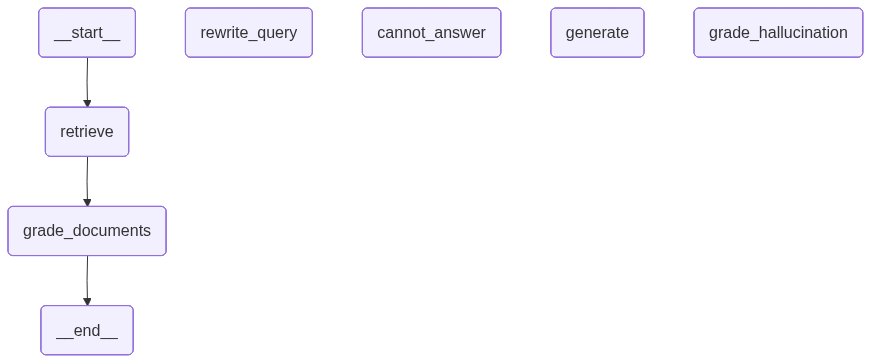

In [98]:
agent

In [99]:
agent.invoke({
  "question": "What in linear regression ?"
 })

{'question': 'What in linear regression ?',
 'documents': [Document(id='43b444f4-824c-4b57-aabb-8fd3c00fa9af', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': '../intro-to-ml.pdf', 'total_pages': 392, 'page': 58, 'page_label': '45'}, page_content='Linear Models\nLinear models are a class of models that are widely used in practice and have been\nstudied extensively in the last few decades, with roots going back over a hundred\nyears. Linear models make a prediction using a linear function of the input features,\nwhich we will explain shortly.\nLinear models for regression\nFor regression, the general prediction formula for a linear mod